Chatbot Reading Existing Memories

In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

C:\Users\manoj\PycharmProjects\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ----------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------
store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Shashank"})
store.put(user_details, "profile_2", {"data": "Profession: Teaches AI on YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [11]:
# ----------------------------
# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Shashank...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..."
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

# ----------------------------
# 3) Build graph: START -> chat -> END (read-only LTM)
# ----------------------------
llm = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')

In [6]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

In [8]:
graph = builder.compile(store=store)

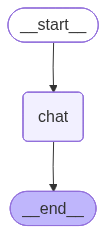

In [9]:
graph

In [10]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}
input = {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]}


result = graph.invoke( input=input, config=config)

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Sure, Shashank. Since you teach AI on YouTube, you’re likely familiar with the distinction, but here is a simple way to explain it to your audience:\n\n**Generative AI (GenAI)** is a type of artificial intelligence that can create **new** content—like text, images, or code—rather than just analyzing or classifying existing data. \n\nThink of it this way:\n*   **Traditional AI** is like a critic: It looks at a photo and tells you, "This is a cat."\n*   **Generative AI** is like an artist: You tell it "Give me a cat wearing a space helmet," and it creates a brand-new image from scratch.\n\n### Python Example\nFor your Python-based projects, here is the simplest way to represent GenAI using the OpenAI library:\n\n```python\nimport openai\n\n# A simple call to a Generative model\nresponse = openai.ChatCompletion.create(\n    model="gpt-4o",\n    messages=[{"role": "user", "content": "Explain GenAI in one sentence."}]\n)\n\nprint(response.choices[0].message.conten

Chatbot Creating New Memories

In [ ]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore